In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise import accuracy
from surprise.model_selection import train_test_split

In [5]:
DATA_DIR = "../data/news-portal-user-interactions-by-globocom/clicks/"

click_files = sorted(glob.glob(os.path.join(DATA_DIR, "clicks", "*.csv")))

print(f"Nombre de fichiers trouvés : {len(click_files)}")
click_files[:5]

Nombre de fichiers trouvés : 385


['../data/news-portal-user-interactions-by-globocom/clicks/clicks/clicks_hour_000.csv',
 '../data/news-portal-user-interactions-by-globocom/clicks/clicks/clicks_hour_001.csv',
 '../data/news-portal-user-interactions-by-globocom/clicks/clicks/clicks_hour_002.csv',
 '../data/news-portal-user-interactions-by-globocom/clicks/clicks/clicks_hour_003.csv',
 '../data/news-portal-user-interactions-by-globocom/clicks/clicks/clicks_hour_004.csv']

In [6]:
clicks = pd.concat((pd.read_csv(f) for f in click_files), ignore_index=True)


print(clicks.shape)
clicks.head()

(2988181, 12)


,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2


In [7]:
clicks.columns.tolist()

['user_id',
 'session_id',
 'session_start',
 'session_size',
 'click_article_id',
 'click_timestamp',
 'click_environment',
 'click_deviceGroup',
 'click_os',
 'click_country',
 'click_region',
 'click_referrer_type']

In [8]:
df = clicks[["user_id", "click_article_id"]].copy()

df = df.dropna()
df["user_id"] = df["user_id"].astype(int)
df["click_article_id"] = df["click_article_id"].astype(int)

print(df.shape)
df.head()

(2988181, 2)


,user_id,click_article_id
0,0,157541
1,0,68866
2,1,235840
3,1,96663
4,2,119592


In [9]:
df_cf = (
    df.groupby(["user_id", "click_article_id"])
      .size()
      .reset_index(name="rating")
)

print(df_cf.shape)
df_cf.head()

(2950710, 3)


,user_id,click_article_id,rating
0,0,68866,1
1,0,87205,1
2,0,87224,1
3,0,96755,1
4,0,157541,1


In [10]:
df_cf["rating"].describe()

count    2.950710e+06
mean     1.012699e+00
std      1.344699e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.300000e+01
Name: rating, dtype: float64

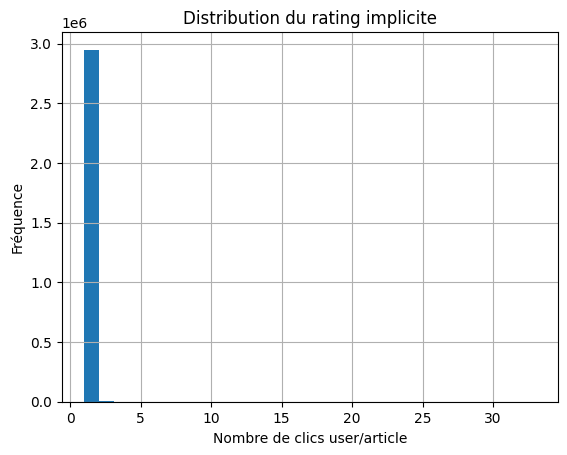

In [11]:
df_cf["rating"].hist(bins=30)
plt.title("Distribution du rating implicite")
plt.xlabel("Nombre de clics user/article")
plt.ylabel("Fréquence")
plt.show()

In [12]:
user_counts = df_cf["user_id"].value_counts()
item_counts = df_cf["click_article_id"].value_counts()

valid_users = user_counts[user_counts >= 3].index
valid_items = item_counts[item_counts >= 3].index

df_cf_filtered = df_cf[
    df_cf["user_id"].isin(valid_users) &
    df_cf["click_article_id"].isin(valid_items)
].copy()

print("Avant filtrage :", df_cf.shape)
print("Après filtrage :", df_cf_filtered.shape)

Avant filtrage : (2950710, 3)
Après filtrage : (2719362, 3)


In [13]:
df_surprise = df_cf_filtered[["user_id", "click_article_id", "rating"]].copy()

rating_min = df_surprise["rating"].min()
rating_max = df_surprise["rating"].max()

print(f"Rating min : {rating_min}")
print(f"Rating max : {rating_max}")

Rating min : 1
Rating max : 31


In [14]:
reader = Reader(rating_scale=(rating_min, rating_max))

data = Dataset.load_from_df(
    df_surprise[["user_id", "click_article_id", "rating"]],
    reader
)

In [15]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("Trainset construit")
print("Taille testset :", len(testset))

Trainset construit
Taille testset : 543873


In [16]:
algo = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

algo.fit(trainset)

In [17]:
predictions = algo.test(testset)

rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.1264
MAE:  0.0279


In [18]:
pred_df = pd.DataFrame(predictions)
pred_df.head()

,uid,iid,r_ui,est,details
0,173752,187445,1.0,1.041493,{'was_impossible': False}
1,89958,254740,1.0,1.006310,{'was_impossible': False}
2,81008,277492,1.0,1.000000,{'was_impossible': False}
3,125968,233717,1.0,1.000000,{'was_impossible': False}
4,1416,214631,1.0,1.003385,{'was_impossible': False}


In [19]:
def get_seen_items(df_interactions, user_id):
    user_data = df_interactions[df_interactions["user_id"] == user_id]
    return set(user_data["click_article_id"].tolist())

In [20]:
def predict_unseen_items(algo, df_interactions, user_id, candidate_items):
    seen_items = get_seen_items(df_interactions, user_id)
    unseen_items = [item for item in candidate_items if item not in seen_items]

    predictions = []
    for item_id in unseen_items:
        pred = algo.predict(uid=user_id, iid=item_id)
        predictions.append((item_id, pred.est))

    return predictions

In [21]:
def get_top_n_recommendations(algo, df_interactions, user_id, all_items, n=5):
    predictions = predict_unseen_items(
        algo=algo,
        df_interactions=df_interactions,
        user_id=user_id,
        candidate_items=all_items
    )

    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
    return predictions[:n]

In [22]:
all_items = df_surprise["click_article_id"].unique().tolist()
sample_user = df_surprise["user_id"].iloc[0]

top_5 = get_top_n_recommendations(
    algo=algo,
    df_interactions=df_surprise,
    user_id=sample_user,
    all_items=all_items,
    n=5
)

top_5

[(38823, 2.4208524178051745),
 (43032, 2.2067300153899034),
 (96173, 2.196263669023722),
 (225378, 1.9158370105804592),
 (105941, 1.9029541794702667)]

In [23]:
top_5_df = pd.DataFrame(top_5, columns=["article_id", "predicted_score"])
top_5_df

,article_id,predicted_score
0,38823,2.420852
1,43032,2.206730
2,96173,2.196264
3,225378,1.915837
4,105941,1.902954


In [25]:
articles_metadata = pd.read_csv(os.path.join(DATA_DIR, "../articles_metadata.csv"))
articles_metadata.head()

,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162


In [26]:
top_5_meta = top_5_df.merge(
    articles_metadata,
    left_on="article_id",
    right_on="article_id",
    how="left"
)

top_5_meta.head()

,article_id,predicted_score,category_id,created_at_ts,publisher_id,words_count
0,38823,2.420852,60,1504598401000,0,262
1,43032,2.206730,68,1402293601000,0,148
2,96173,2.196264,209,1502368298000,0,204
3,225378,1.915837,354,1506449125000,0,205
4,105941,1.902954,228,1491861426000,0,145
